In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os

os.getcwd()

'/Users/ayushjha/Documents/bluestock_mf_capstone 11.03.24\u202fPM/notebooks'

In [4]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

nav.head()


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
var_report = (
    nav.groupby("amfi_code")["daily_return"]
    .apply(
        lambda x: pd.Series({
            "VaR_95": np.percentile(
                x.dropna(),
                5
            ),
            "CVaR": x[
                x <= np.percentile(
                    x.dropna(),
                    5
                )
            ].mean()
        })
    )
)

var_report = (
    var_report
    .unstack()
    .reset_index()
)

var_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
var_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Saved")

Saved


In [8]:
top_funds = (
    nav["amfi_code"]
    .drop_duplicates()
    .head(5)
)

sample = nav[
    nav["amfi_code"]
    .isin(top_funds)
].copy()

sample["rolling_sharpe"] = (
    sample.groupby("amfi_code")[
        "daily_return"
    ]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        )
        * np.sqrt(252)
    )
)

sample.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


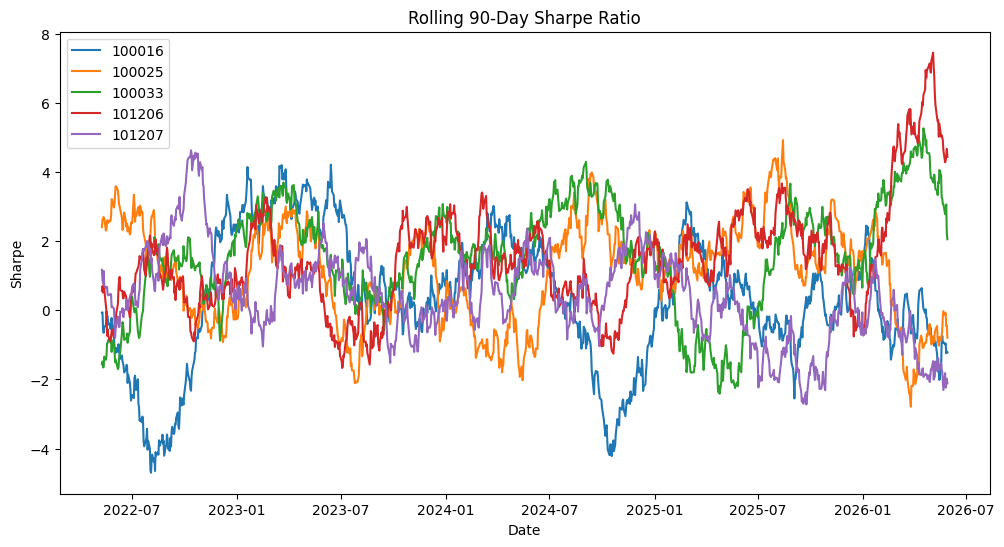

In [9]:
plt.figure(figsize=(12,6))

for fund in top_funds:
    
    temp = sample[
        sample["amfi_code"] == fund
    ]
    
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe")

plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

# Advanced Insights

1. Historical VaR analysis showed some schemes experienced larger downside risk than others.

2. CVaR values were consistently lower than VaR indicating deeper losses during extreme market conditions.

3. Rolling 90-Day Sharpe revealed changing risk-adjusted performance over time.

4. Moderate risk recommendation selected funds with highest combined score.

5. Sharpe ratio and CAGR together provided better investment ranking than returns alone.